In [8]:
import torch
from transformers import AutoImageProcessor, AutoModel
processor = AutoImageProcessor.from_pretrained("facebook/dinov3-vit7b16-pretrain-lvd1689m")
model = AutoModel.from_pretrained("facebook/dinov3-vit7b16-pretrain-lvd1689m")

Loading checkpoint shards: 100%|██████████| 6/6 [00:00<00:00, 11.51it/s]


In [15]:

from transformers.image_utils import load_image 

url = "/home/ubuntu/stuff/REG2/dataset/images/00000/img00000001.png"
image = load_image(url)
print("Image size:", image.height, image.width)  # [480, 640]


patch_size = model.config.patch_size
print("Patch size:", patch_size) # 16
print("Num register tokens:", model.config.num_register_tokens) # 4

inputs = processor(images=image, return_tensors="pt", do_resize=False, do_center_crop=False)
print("Preprocessed image size:", inputs.pixel_values.shape)  # [1, 3, 224, 224]

batch_size, _, img_height, img_width = inputs.pixel_values.shape
num_patches_height, num_patches_width = img_height // patch_size, img_width // patch_size
num_patches_flat = num_patches_height * num_patches_width

with torch.inference_mode():
  outputs = model(**inputs)

last_hidden_states = outputs.last_hidden_state[0].to(torch.float32).cuda()
print(last_hidden_states.shape)  # [1, 1 + 4 + 256, 384]

Image size: 256 256
Patch size: 16
Num register tokens: 4
Preprocessed image size: torch.Size([1, 3, 256, 256])
torch.Size([261, 4096])


In [ ]:
import numpy as np
import torch


cls_tokesn = []
for i in range(1000):
    pre_dino = np.load(f"/home/ubuntu/stuff/REG2/dataset/dinov3-vit7b16/00000/img-dinov3-{i:07d}_hidden.npy")
    pre_dino = torch.from_numpy(pre_dino).to(torch.float32).cuda()
    cls_tokesn.append(pre_dino[0, 0, :].cpu().numpy())

plt.plot(cls_tokesn)
plt.show()


In [19]:
clstok = pre_dino[0]

In [24]:
clstok.shape

torch.Size([4096])

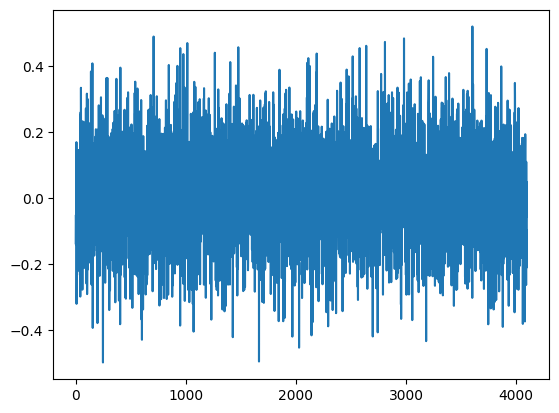

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# plot different dimensions
plt.plot(clstok[ :].cpu().numpy())
plt.show()
